# Spatiotemporal Analysis
February 23, 2024

### Further spatiotemporal characterization of deconvolved chromatin bins

1. What is the timing of these cycling bins? Which cell phases?
- An easy way to start this analysis is check for the cycling bins, do they correlate well with the cycling gene expression?

2. What is the location of the cell cycling bins?
And, this may improve the signal, does categorizing the bins as small fragment or nucleosome sized, or promoter vs gene body help with this analysis?

#### Procedure for temporal analysis correlation with gene expression
1. Compute the index (in f) of the PTR values. One for the peak, and one for the trough.
    - Start with reading in the deconvolved f values, but eventually we can build this into the deconvolution algorithm.
2. Plot a scatter plot of the peak to trough locations with the gene expression peak to trough locations.
    - The data points of the scatter plot: to be determined.
    - Calculate a correlation
    - How does the Spellman genes hold up to this analysis?
    


In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel

config = load_yl_rg1_vst_config(1)
chromatin_model = ChromatinModel(config)
gene_name = 'CDC5'
chromatin_model.load_mnase_gene(gene_name)


In [152]:
chromatin_model.create_deconvolution_bins()

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [153]:
chromatin_model.deconvolve()

Deconvolving with gamma=0.006, gamma_prime=0
Deconvolved in : 00:01:28.94
The fitting norm is 5.30, the smoothing norm is: 10.40


In [154]:
from src.model import Model
ge_model = Model(config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

In [155]:
chromatin_model.compute_ptr()

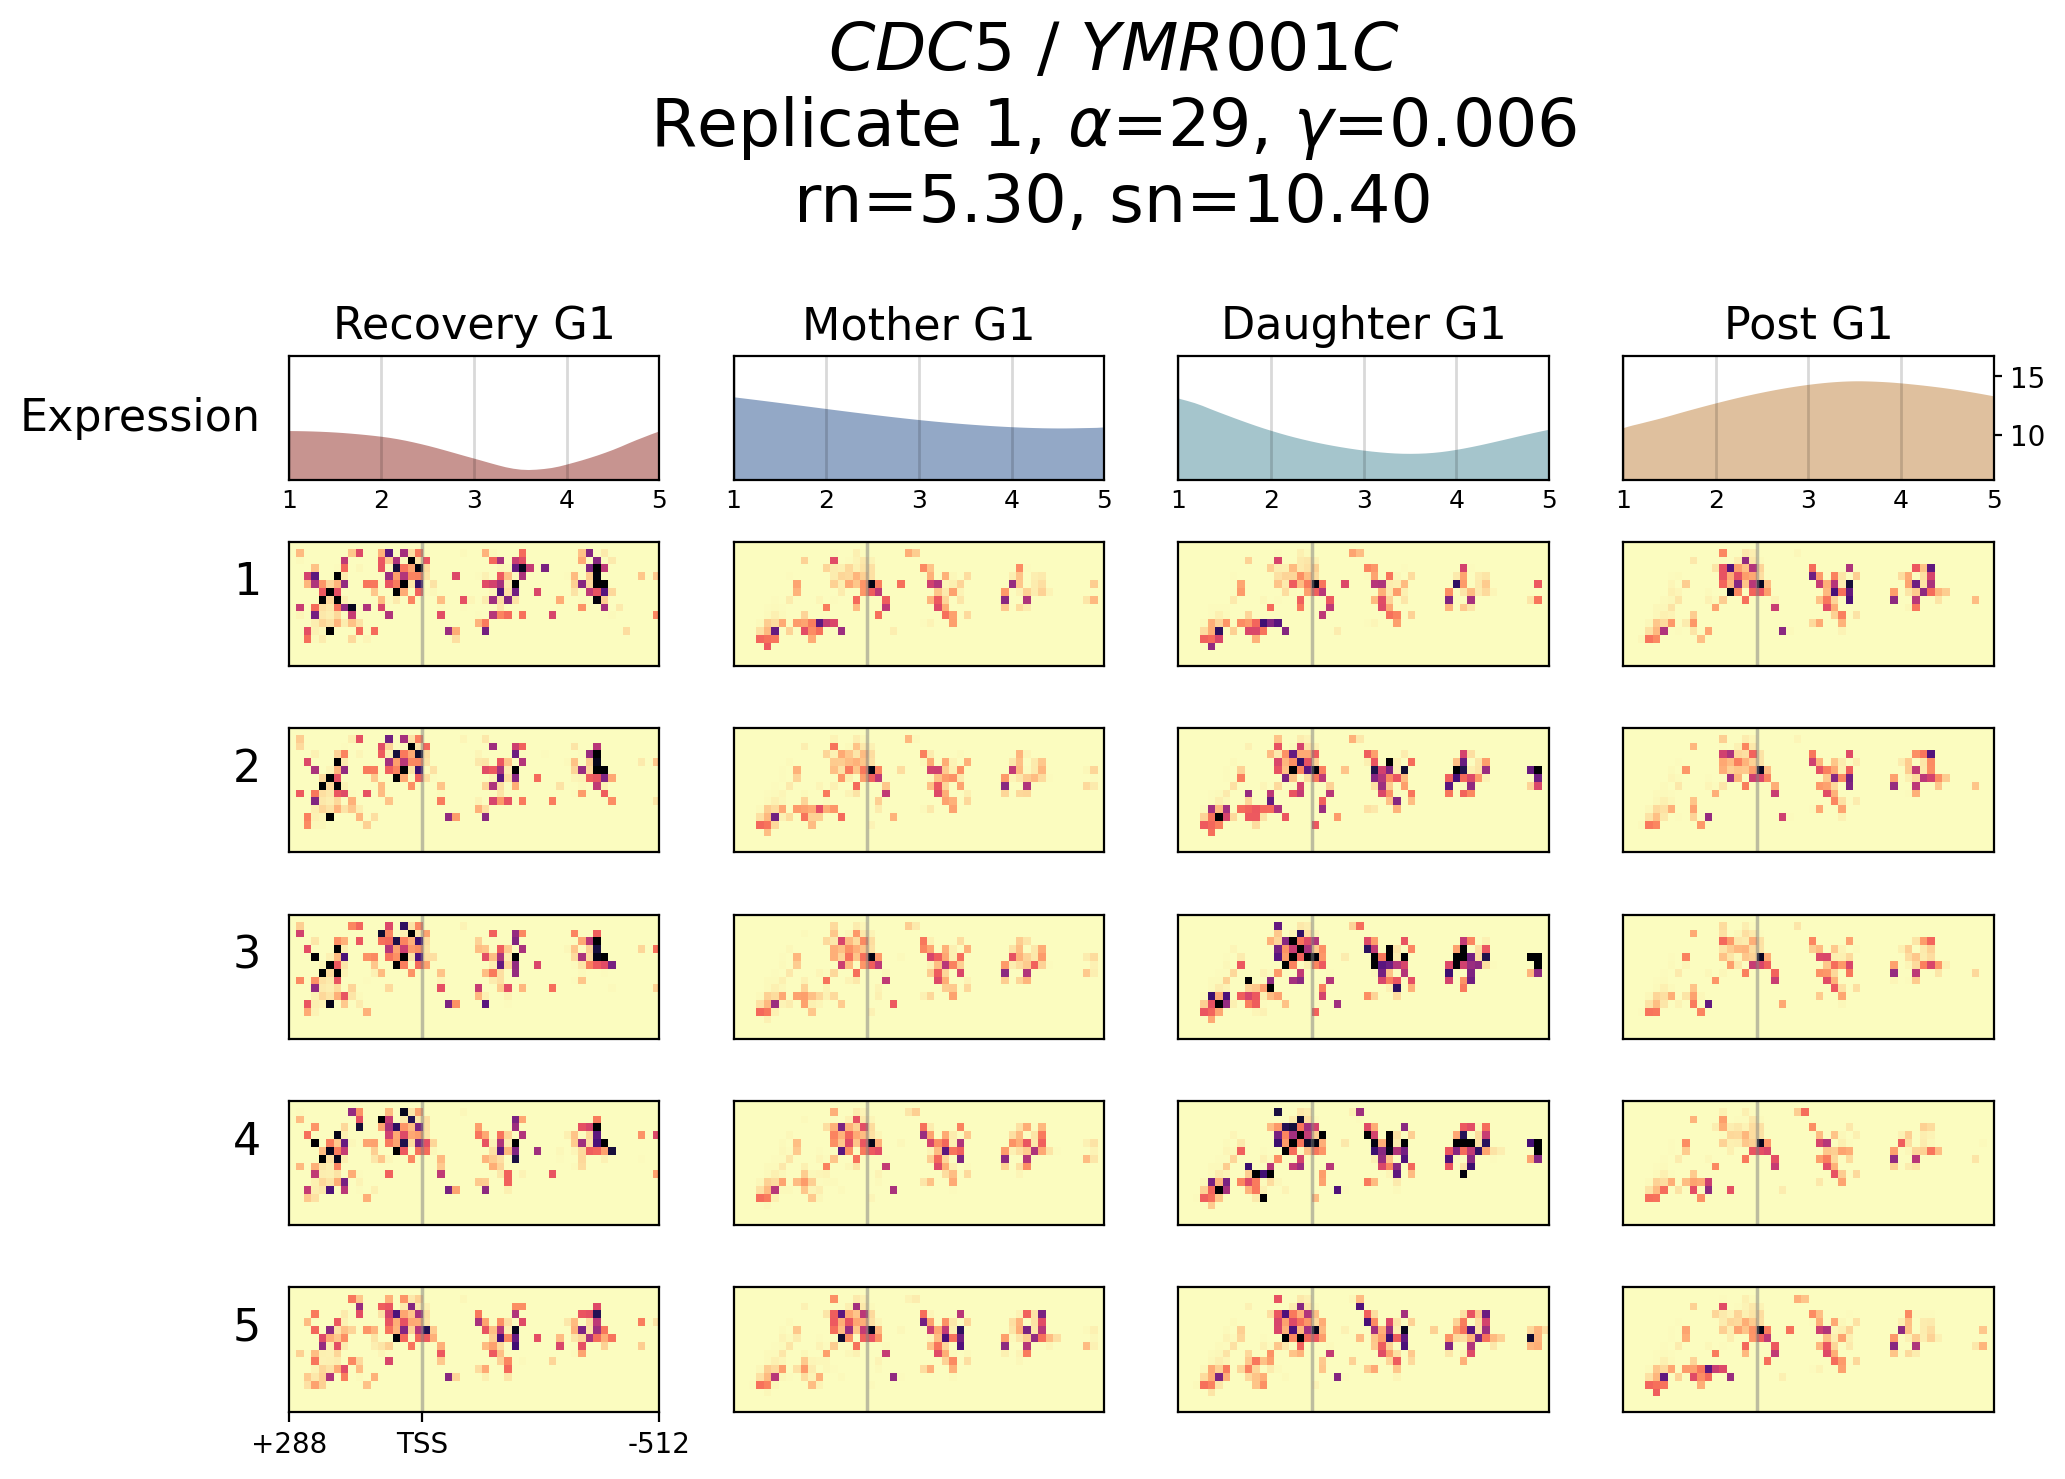

In [156]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model)

In [157]:
chromatin_model.compute_ptr()

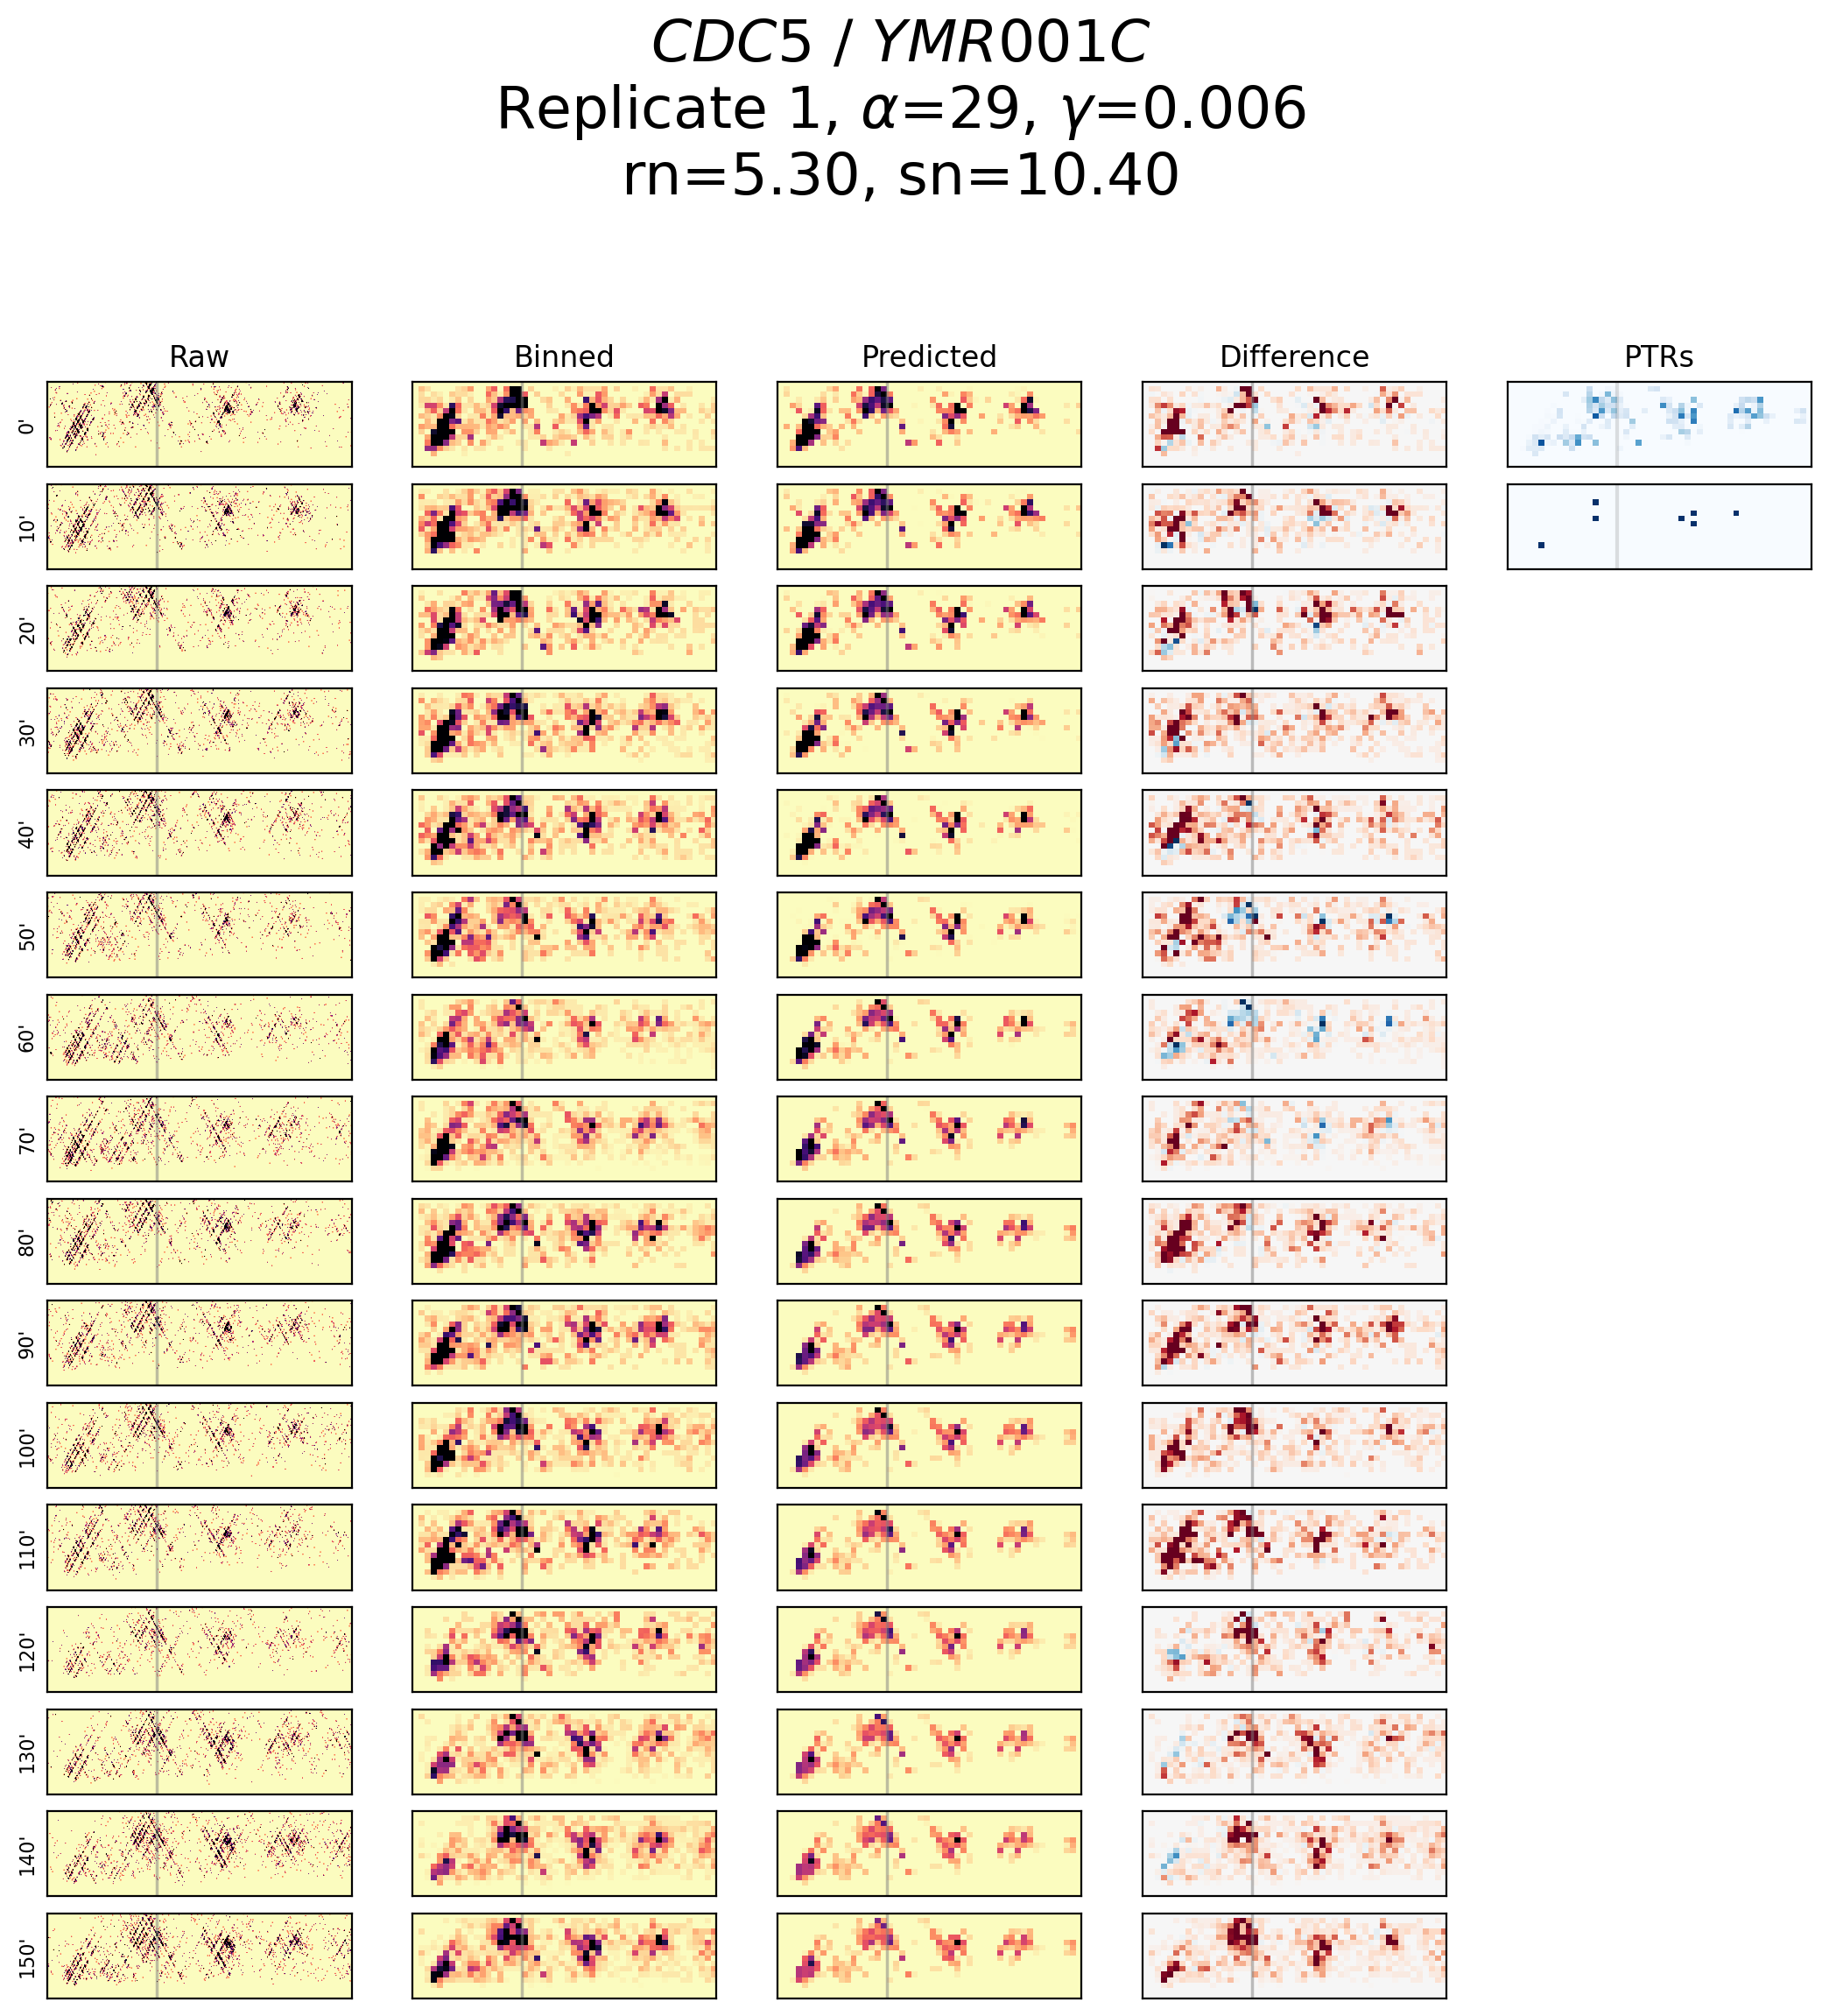

In [158]:
fig = chromatin_model.plot_prediction_comparison()

In [159]:
m = chromatin_model.G.shape[1]
f_rank_indices = np.arange(m)[chromatin_model.f_ranks < 7]

113.85900000000001

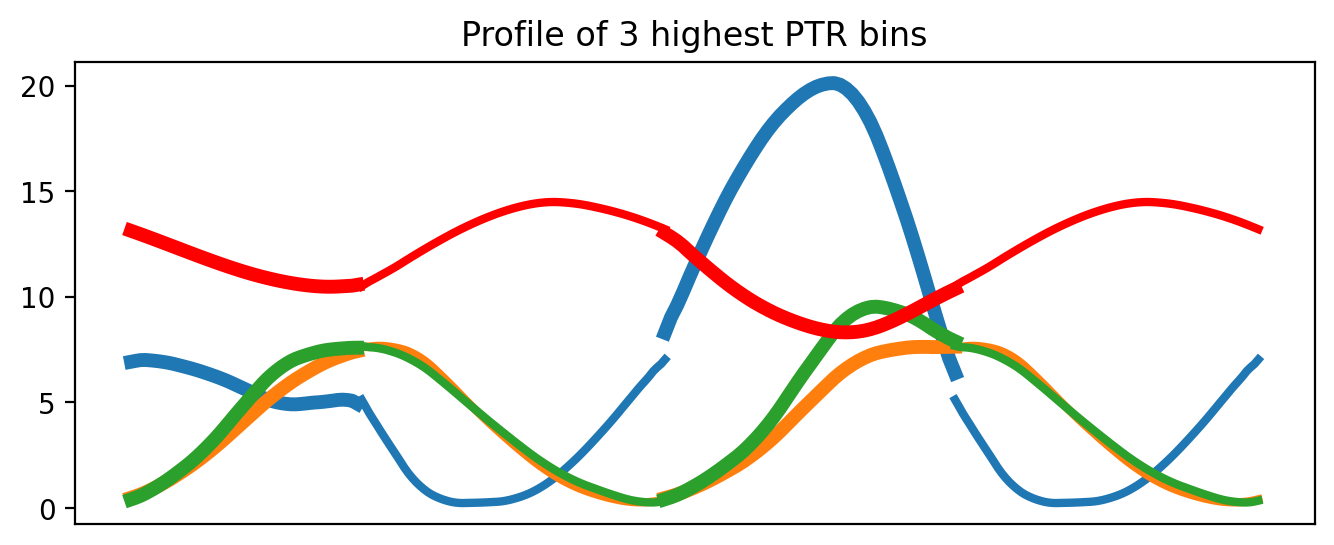

In [167]:
f = chromatin_model.solver.f.value
f_k_values = f[:, f_rank_indices].copy()

# Get the timepoints for CG1-postG1-DG1-postG1
# and plot these

# We'll do the same with gene expression and see if we can plot
# these aligned with another
# We may need to think about how to do this analysis further.
#  .....

deconv_model = chromatin_model.deconv_model

from src.model import color_for_key

def plot_branch(deconv_model, branch, f_k_values, chrom_index, offset=0,
               color=None):
    return plot_f_values_branch(deconv_model, branch, f_k_values[:, chrom_index], offset,
               color)

def plot_f_values_branch(deconv_model, branch, f_k_values, offset=0, color=None):
    tp_phases_df = deconv_model.config.get_timepoints_phases_Hpositions_for_branch(branch)

    for i in range(len(tp_phases_t)):
        phase = tp_phases_df[i][0]
        tps = tp_phases_df[i][1]
        current_indices = tp_phases_df[i][2]
        cur_f_values = f_k_values[current_indices]
        
        if offset > 0:            
            tps = tps - tps.values[0] + offset
            offset = tps.values[-1]

        lw = 3 if i > 0 else 5
        plt.plot(tps, cur_f_values, color=color, lw=lw)
        plt.xticks([])
        
    return tps.values[-1]

cmap = plt.get_cmap('tab10')
colors = [cmap(0), cmap(1), cmap(2)]

plt.figure(figsize=(8, 3))
plt.title("Profile of 3 highest PTR bins")
for chrom_index in [0, 1, 2]:
    last_tp = plot_branch(deconv_model, 't', f_k_values, chrom_index,
                         color=colors[chrom_index])
    plot_branch(deconv_model, 'b', f_k_values, chrom_index, offset=last_tp,
               color=colors[chrom_index])

    
# -------- Gene expression -------

last_tp = plot_f_values_branch(deconv_model, 't', ge_model.f, color='red')
plot_f_values_branch(deconv_model, 'b', ge_model.f, offset=last_tp,
           color='red')


In [29]:
from src.config import load_yl_rg1_vst_config

config = load_yl_rg1_vst_config(1)
chromatin_model = ChromatinModel(config)
gene_name = 'YPR204W'
chromatin_model.load_mnase_gene(gene_name)


Loading MNase reads for YPR204W/None...Error finding plus one location, possibly not enough read coverage. Setting plus one to TSS by default
Done.


In [33]:
chromatin_model.create_deconvolution_bins()
chromatin_model.deconvolve(verbose=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)
Deconvolving with gamma=0.006, gamma_prime=0


ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [31]:
chromatin_model.solver.f.value

In [ ]:
chromatin_model.define_title()

In [ ]:
from src.model import Model
ge_model = Model(config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

In [ ]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model)